### Module 7: Matplotlib visualization

**Turning Aishmita's tables into pictures.** Four charts, each answering one of the questions we
set out to answer: which city has the worst air, how AQI moves through the year, how PM2.5 relates
to AQI, and what the overall pollutant levels look like.


In [34]:
import matplotlib.pyplot as plt
%matplotlib inline


**1. Average AQI by city.**

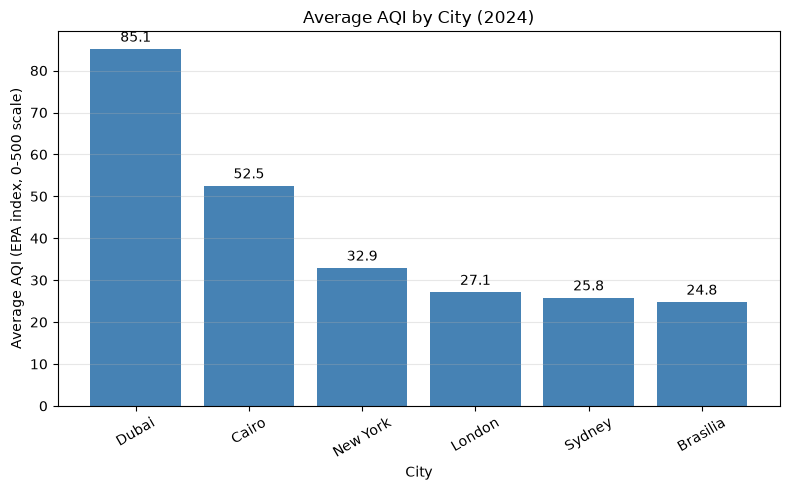

In [35]:
def plot_avg_aqi_by_city(city_summary):
    """Bar chart of average AQI by city, with value labels on each bar."""
    city_order = city_summary.index  # already sorted by AQI, highest first
    plt.figure(figsize=(8, 5))
    bars = plt.bar(city_order, city_summary["AQI"], color="steelblue")
    plt.bar_label(bars, fmt="%.1f", padding=3)
    plt.title("Average AQI by City (2024)")
    plt.xlabel("City")
    plt.ylabel("Average AQI (EPA index, 0-500 scale)")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_avg_aqi_by_city(city_summary)


Dubai sits well above the other five cities, which matches the `city_summary` table Aishmita built
in Part 2. Brasilia is the cleanest.


**2. AQI trend across the year.**

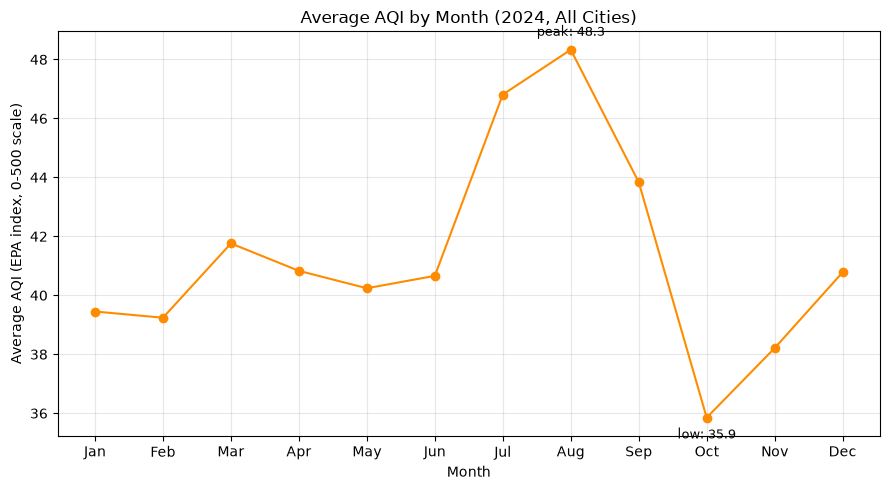

In [36]:
def plot_monthly_aqi_trend(monthly_aqi):
    """Line chart of average AQI by month, with the year's peak and trough called out."""
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    values = monthly_aqi.values

    plt.figure(figsize=(9, 5))
    plt.plot(month_names, values, marker="o", color="darkorange")

    peak_idx = values.argmax()
    trough_idx = values.argmin()
    plt.annotate(f"peak: {values[peak_idx]:.1f}", (month_names[peak_idx], values[peak_idx]),
                 textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
    plt.annotate(f"low: {values[trough_idx]:.1f}", (month_names[trough_idx], values[trough_idx]),
                 textcoords="offset points", xytext=(0, -15), ha="center", fontsize=9)

    plt.title("Average AQI by Month (2024, All Cities)")
    plt.xlabel("Month")
    plt.ylabel("Average AQI (EPA index, 0-500 scale)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_monthly_aqi_trend(monthly_aqi)


AQI stays in a fairly narrow band all year, with July and August clearly the worst months and
October the cleanest. We used a line chart because this is a trend over time, not a comparison
between separate categories.


**3. PM2.5 versus AQI.**

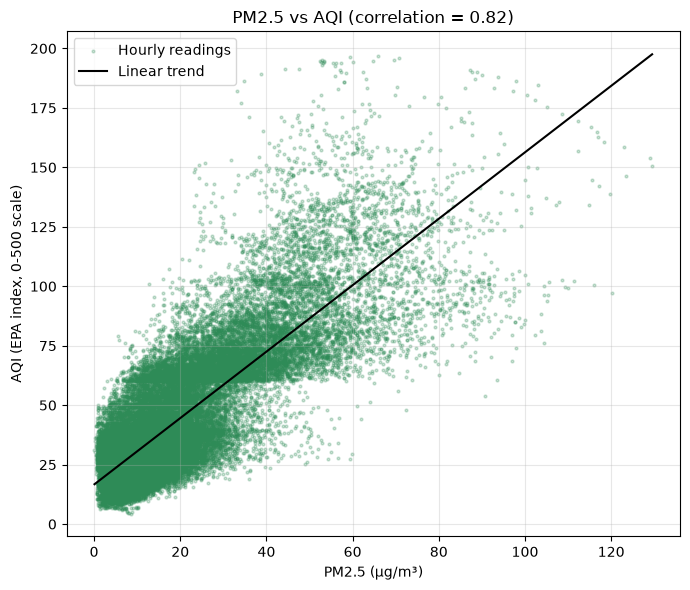

In [37]:
def plot_pm25_vs_aqi(df, correlation):
    """Scatter plot of PM2.5 vs AQI, with a linear trend line to show the correlation visually."""
    x = df["PM2.5"]
    y = df["AQI"]
    slope, intercept = np.polyfit(x, y, 1)
    trend_x = np.array([x.min(), x.max()])
    trend_y = slope * trend_x + intercept

    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, s=4, alpha=0.25, color="seagreen", label="Hourly readings")
    plt.plot(trend_x, trend_y, color="black", linewidth=1.5, label="Linear trend")
    plt.title(f"PM2.5 vs AQI (correlation = {correlation:.2f})")
    plt.xlabel("PM2.5 (µg/m³)")
    plt.ylabel("AQI (EPA index, 0-500 scale)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_pm25_vs_aqi(df, pm25_aqi_corr)


The upward pattern is obvious just from the shape of the cloud of points, which backs up the 0.82
correlation we calculated with NumPy above.


**4. Average pollutant levels overall.**

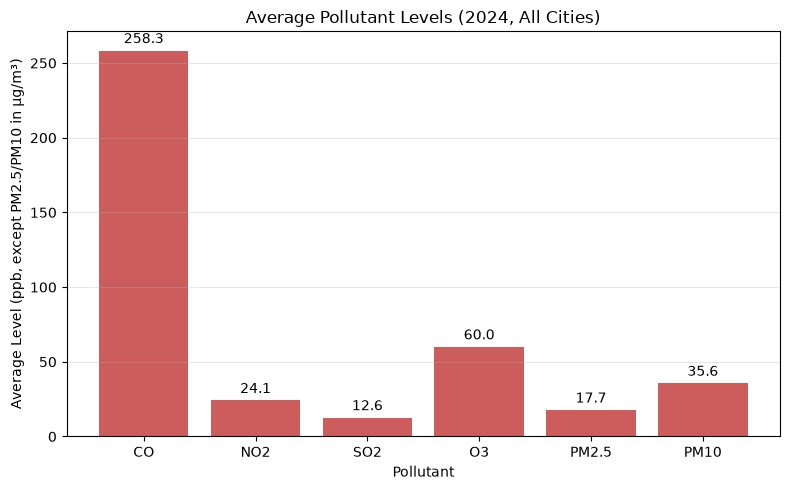

In [38]:
def plot_overall_pollutant_levels(df):
    """Bar chart of overall average pollutant levels, with each bar labeled since units differ by pollutant."""
    overall_avg = df[["CO", "NO2", "SO2", "O3", "PM2.5", "PM10"]].mean().round(1)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(overall_avg.index, overall_avg.values, color="indianred")
    plt.bar_label(bars, fmt="%.1f", padding=3)
    plt.title("Average Pollutant Levels (2024, All Cities)")
    plt.xlabel("Pollutant")
    plt.ylabel("Average Level (ppb, except PM2.5/PM10 in µg/m³)")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_overall_pollutant_levels(df)


CO sits on a completely different scale from the others, which is just a unit difference (CO is
measured in much larger numbers than PM2.5 or PM10) rather than CO being 10x more "present" in the
air.
